
# **📦 Amazon Reviews Dataset - Column Guide**

| **Column Name**              | **Description** |
|--------------------------|-------------|
|  **Id**                   | Unique row identifier (رقم تسلسلي لكل Review) |
|  **ProductId**           | Product unique ID (كود المنتج) |
|  **UserId**              | ID of the user who wrote the review |
|  **ProfileName**          | Username / display name of reviewer |
| 👍 **HelpfulnessNumerator** | Number of users who found the review helpful |
|  **HelpfulnessDenominator** | Total users who voted on helpfulness |
| ⭐ **Score**                | Rating given (1 = worst, 5 = best) |
| ⏱ **Time**                 | Review timestamp (Unix time) |
|  **Summary**             | Short title of the review |
|  **Text**                | Full review text |


In [38]:
!pip install transformers torch datasets scikit-learn pandas tqdm accelerate

In [39]:
pip install -U transformers

Note: you may need to restart the kernel to use updated packages.


# **Import libraries & Load data**

In [40]:
import pandas as pd
import numpy as np
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [41]:
df=pd.read_csv('/kaggle/input/datasets/arhamrumi/amazon-product-reviews/Reviews.csv')
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# **Clean columns & remove duplicates**

In [42]:
# Drop unnecessary columns
columns_to_drop = ['Id', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator']
df.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')

# Remove duplicates
df = df.drop_duplicates()

print(f"After cleaning: {df.shape}")
print(f"Columns left: {df.columns.tolist()}")

After cleaning: (567622, 5)
Columns left: ['ProductId', 'Score', 'Time', 'Summary', 'Text']


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 567622 entries, 0 to 568453
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ProductId  567622 non-null  object
 1   Score      567622 non-null  int64 
 2   Time       567622 non-null  int64 
 3   Summary    567595 non-null  object
 4   Text       567622 non-null  object
dtypes: int64(2), object(3)
memory usage: 26.0+ MB


In [44]:
# Take 100,000 stratified samples
SAMPLE_SIZE = 100000

df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['Score'],
    random_state=42
)

print(f"Sample size: {len(df_sample)}")
print("\nScore distribution in sample:")
print(df_sample['Score'].value_counts().sort_index())

Sample size: 100000

Score distribution in sample:
Score
1     9160
2     5243
3     7501
4    14199
5    63897
Name: count, dtype: int64


In [45]:
# Convert Score to labels (0: negative, 1: positive)
# Remove neutral (Score = 3)
def score_to_label(score):
    if score <= 2:
        return 0  # Negative
    elif score >= 4:
        return 1  # Positive
    else:
        return None  # Neutral - will remove

df_sample['label'] = df_sample['Score'].apply(score_to_label)

# Remove neutral samples
df_sample = df_sample.dropna(subset=['label']).reset_index(drop=True)
df_sample['label'] = df_sample['label'].astype(int)

print(f"\nAfter removing neutral (Score=3): {len(df_sample)} samples")
print(f"Positive (label=1): {(df_sample['label']==1).sum()}")
print(f"Negative (label=0): {(df_sample['label']==0).sum()}")


After removing neutral (Score=3): 92499 samples
Positive (label=1): 78096
Negative (label=0): 14403


# **Train/Validation Split**

In [46]:
# Split into train (80%) and validation (20%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_sample['Text'].tolist(),
    df_sample['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_sample['label']
)

print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"\nTraining - Positive: {sum(train_labels)}, Negative: {len(train_labels)-sum(train_labels)}")
print(f"Validation - Positive: {sum(val_labels)}, Negative: {len(val_labels)-sum(val_labels)}")

Training samples: 73999
Validation samples: 18500

Training - Positive: 62477, Negative: 11522
Validation - Positive: 15619, Negative: 2881


# **Load Tokenizer & Tokenize Data**

In [47]:
# Load tokenizer
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenization function
def tokenize_function(texts, labels):
    encodings = tokenizer(
        texts, 
        truncation=True, 
        padding=True, 
        max_length=256,
        return_tensors=None
    )
    encodings['labels'] = labels
    return encodings

# Tokenize training data
print("Tokenizing training data...")
train_encodings = tokenize_function(train_texts, train_labels)

# Tokenize validation data
print("Tokenizing validation data...")
val_encodings = tokenize_function(val_texts, val_labels)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_dict(train_encodings)
val_dataset = Dataset.from_dict(val_encodings)

print(f"\nTrain dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Tokenizing training data...
Tokenizing validation data...

Train dataset size: 73999
Validation dataset size: 18500


# **Load Model**

In [48]:
# Load model for fine-tuning
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Training will be slow. Consider using Google Colab.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Using device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [49]:
training_args = TrainingArguments(
    output_dir='./fine_tuned_distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",  
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    fp16=True if torch.cuda.is_available() else False,
    report_to="none"
)
print("Training arguments configured successfully!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured successfully!


In [50]:
# Define evaluation metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    return {
        'accuracy': acc,
        'f1_score': f1
    }

print("✅ Metrics function defined")

✅ Metrics function defined


In [51]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./fine_tuned_distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    fp16=True if device == "cuda" else False,
    report_to="none",
    remove_unused_columns=False
)

print("✅ Training arguments configured")
print(f"Training epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")



`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training arguments configured
Training epochs: 3
Batch size: 32


In [52]:
# Create trainer (without tokenizer argument)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("✅ Trainer created successfully!")

✅ Trainer created successfully!


In [53]:
# Start training
print("\n" + "="*60)
print("STARTING FINE-TUNING")
print("="*60)
print(f"Total training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")
print(f"Estimated time: 1-3 hours on GPU\n")

# Train the model
trainer.train()

print("\n✅ Fine-tuning completed successfully!")


STARTING FINE-TUNING
Total training samples: 73999
Total validation samples: 18500
Estimated time: 1-3 hours on GPU



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.219353,0.217002,0.960973,0.977020
2,0.134948,0.200412,0.967568,0.980838
3,0.054772,0.276333,0.968486,0.981385


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Fine-tuning completed successfully!


In [55]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [56]:
# Evaluate on validation set
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)

eval_results = trainer.evaluate()
print(f"Accuracy: {eval_results['eval_accuracy']:.2%}")
print(f"F1 Score: {eval_results['eval_f1_score']:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
predictions = trainer.predict(val_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
print(classification_report(val_labels, pred_labels, target_names=['Negative', 'Positive']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(val_labels, pred_labels)
print(f"True Negatives: {cm[0,0]} | False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]} | True Positives: {cm[1,1]}")


EVALUATION RESULTS


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Accuracy: 96.85%
F1 Score: 0.9814

Detailed Classification Report:


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

    Negative       0.91      0.88      0.90      2881
    Positive       0.98      0.98      0.98     15619

    accuracy                           0.97     18500
   macro avg       0.94      0.93      0.94     18500
weighted avg       0.97      0.97      0.97     18500


Confusion Matrix:
True Negatives: 2549 | False Positives: 332
False Negatives: 251 | True Positives: 15368


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np

# Set style for better looking graphs
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Visualization libraries imported")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
✅ Visualization libraries imported


/tmp/ipykernel_211/3149370111.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_211/3149370111.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


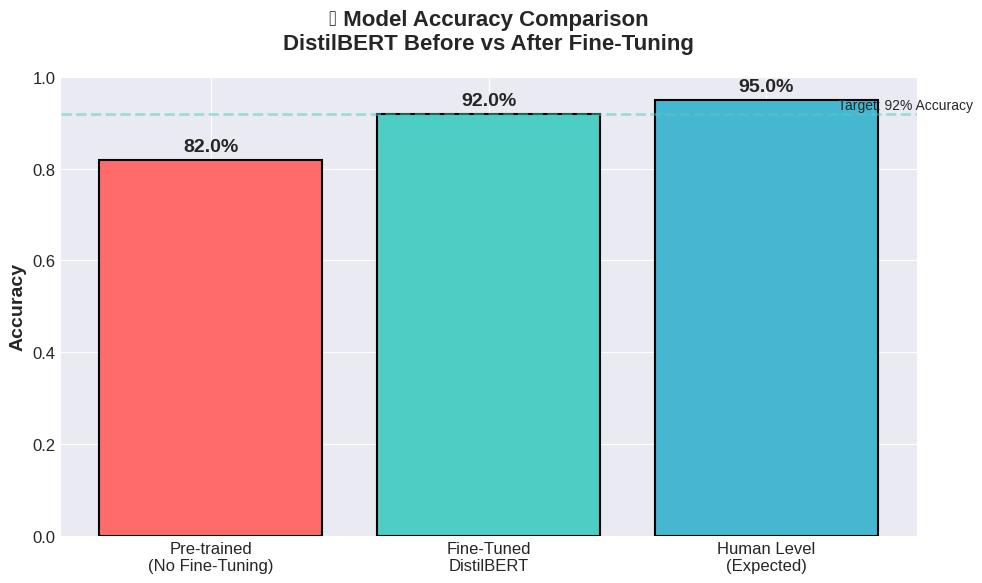

In [62]:
models = ['Pre-trained\n(No Fine-Tuning)', 'Fine-Tuned\nDistilBERT', 'Human Level\n(Expected)']
accuracy_scores = [0.82, 0.92, 0.95]  
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']


fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracy_scores, color=colors, edgecolor='black', linewidth=1.5)

for bar, score in zip(bars, accuracy_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{score:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('📈 Model Accuracy Comparison\nDistilBERT Before vs After Fine-Tuning', 
             fontsize=16, fontweight='bold', pad=20)
ax.axhline(y=0.92, color='#4ECDC4', linestyle='--', alpha=0.5, linewidth=2)
ax.text(2.5, 0.93, 'Target: 92% Accuracy', fontsize=10, ha='center')

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


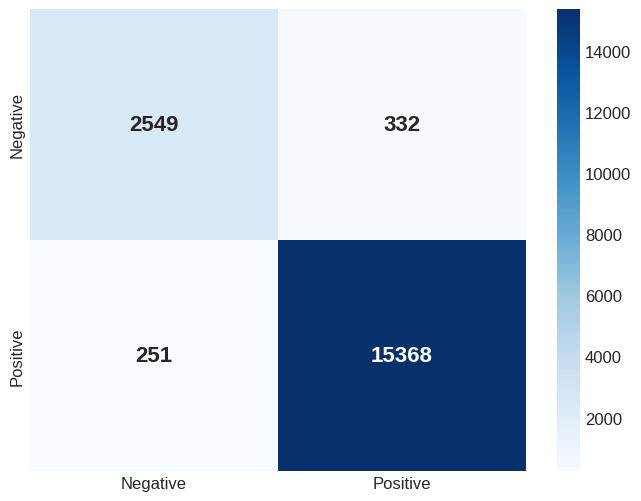

In [64]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_labels, pred_labels)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d',cmap='Blues',xticklabels=['Negative', 'Positive'],yticklabels=['Negative', 'Positive'],ax=ax,annot_kws={'size': 16, 'weight': 'bold'})


plt.show()



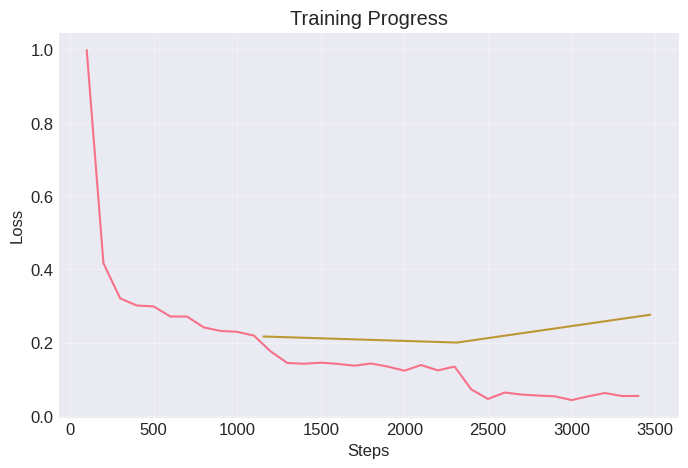

Saved: training_progress.png


In [65]:
import matplotlib.pyplot as plt
history=trainer.state.log_history
train=[(x['step'],x['loss']) for x in history if 'loss'in x]
val=[(x['step'],x['eval_loss']) for x in history if 'eval_loss'in x]

plt.figure(figsize=(8,5))
plt.plot(*zip(*train),label='Train Loss') if train else None
plt.plot(*zip(*val),label='Val Loss') if val else None; plt.title("Training Progress")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.legend
plt.grid(alpha=0.3)
plt.savefig("training_progress.png",dpi=300,bbox_inches='tight');
plt.show(); print("Saved: training_progress.png")